# <font color='12284A' style="font-family: andale mono, monospace; font-size: 28px; text-transform: uppercase">Drum Audio Sample Classifier - Model<font><a class='anchor' id='top'></a>
This portion of the application is used to create the model. It imports, and parses the dataset, creates and fits the model, and finally saves the model to be used by the "drum_prediction" jupyter notebook.
    
I would like the recognize and thank Dr. Papia Nandi for her article "CNNs for Audio Classification". Citation comments are included in code snippets directly adapted from her work and proper citations will be included in Task documentation.

In [1]:
#Imports Modules
import matplotlib.pyplot as plt
import pandas as pd
import os
import librosa
from sklearn.preprocessing import normalize
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras import models, layers
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Get acbsolute path of project
abs_path = os.getcwd()

# Imports csv of dataset metadata
df = pd.read_csv(abs_path + "/dataset/samples_metadata.csv")

# Defines variables that may be changes in the future

# Number of spectrogram frames to use
LENGTH = 22050

# Drum Type Dictionary with indices
drum_types = {
    'clap': 0,
    'closedhat': 1,
    'kick': 2,
    'openhat': 3,
    'snare': 4,
}

In [3]:
# Converts Audio Samples in single Numpy Array to train model

# Gets relative path to audio samples for dataset
samples = abs_path + "/dataset/samples/"

# Create blank lists to fill
samples_data = []
samples_visual_data = []
samples_data_type = []

for sample in sorted(os.listdir(samples)):
    # Blank arrays of zeros to be overwritten by sample data, required to make all sample arrays the same size
    # Array Dimensions are as follows: D1: Pitch Slices (513), D2: Time samples (LENGTH), and D3: value of power/amplitude
    # D3 is duplicated across 3 values in the model version since CNNs were made with RGB (3) image values in mind. It's
    # simpler to make the CNN Model think it is a RGB image than try and make it work for audio specifically
    
    # Load, Trim, and resample the audio file
    audio, sr = librosa.load(samples+sample, sr=22050)
    audio, _ = librosa.effects.trim(audio, top_db=50)
    audio = librosa.resample(y=audio, orig_sr=sr, target_sr=22050)
    
    if len(audio) < LENGTH:
        audio = np.pad(audio, (0, LENGTH - len(audio)))
    else:
        audio = audio[:LENGTH]

    # audio is now LENGTH long: shape into (LENGTH, 1)
    audio = audio.reshape((LENGTH, 1))
    # Adds audio samples into samples_data
    samples_data.append(audio)
    
    # Adds audio samples type of drum to samples_data_type
    samples_data_type.append([val for key,val in drum_types.items() if key in sample])

# Convert Lists to Numpy Arrays
samples_data = np.array(samples_data)
samples_data_type = np.array(samples_data_type)

This is our preprocessing step. Anything we do here must be replicated exactly when we want to sample the final model. Except for the visuals related stuff, which is just for testing and sanity checking before we train the model.

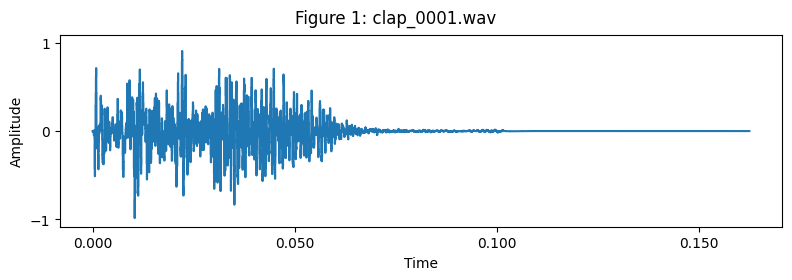

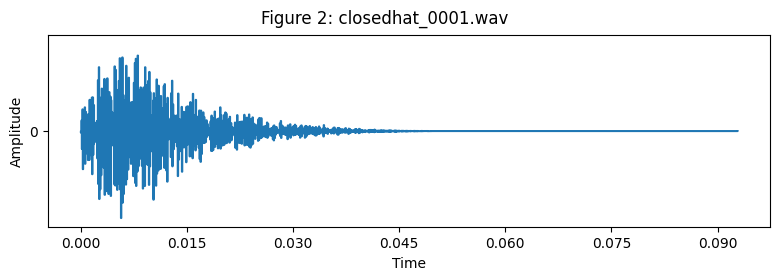

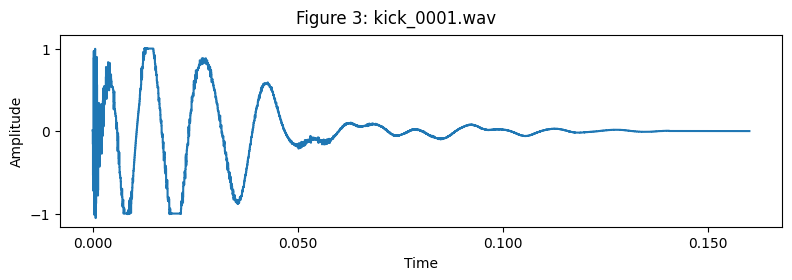

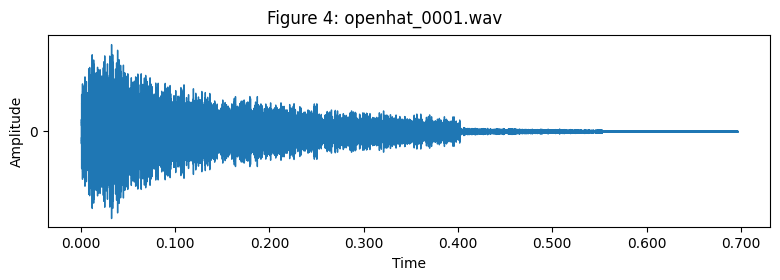

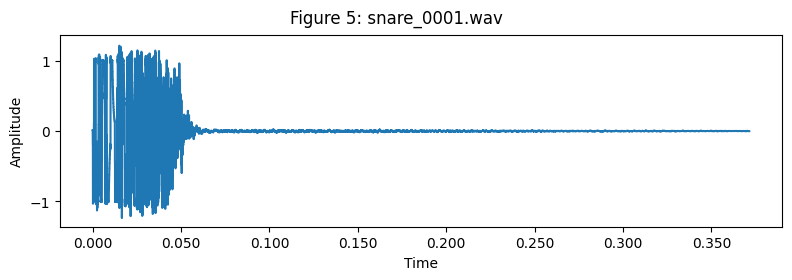

In [4]:
# Outputs Waveform of the first of each Drum Type, conveys amplitude over time
for i, drum in enumerate(drum_types):
    y, sr = librosa.load(samples + drum + '_0001.wav')

    y,z = librosa.effects.trim(y, top_db=50)
    y = librosa.resample(y=y, orig_sr=sr, target_sr=22050)

    plt.figure(figsize=(8, 3))
    plt.suptitle("Figure " + str(i+1) + ": " + drum + '_0001.wav',x=0.5, y=0.915,fontsize=12)
    plt.xlabel("Time")
    plt.ylabel('Amplitude')
    
    plt.xticks(np.arange(0, 1, 1))
    plt.yticks(np.arange(-2, 2, 1))
    plt.tight_layout(pad=1.0)
    
    librosa.display.waveshow(y, sr=sr)

In [15]:
# Split once to get the test and training set
X_train, X_test, y_train, y_test = train_test_split(samples_data, samples_data_type, test_size=0.25, random_state=123)

# Split twice to get the validation set
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=123)

This splits the dataset into 3 sets: training (56%), validation (19%), and test (25%)

In [80]:
# Custom and imported layers

class AudioAugmentation(tf.keras.layers.Layer):
    def __init__(self, 
                 noise_std=0.005,
                 gain_min=0.8,
                 gain_max=1.2,
                 shift_max=2205,
                 time_stretch=True,
                 **kwargs):
        super().__init__(**kwargs)
        self.noise_std = noise_std
        self.gain_min = gain_min
        self.gain_max = gain_max
        self.shift_max = shift_max
        self.time_stretch = time_stretch

    def random_gain(self, x):
        gain = tf.random.uniform([tf.shape(x)[0], 1], self.gain_min, self.gain_max)
        return x * gain

    def random_noise(self, x):
        noise = tf.random.normal(tf.shape(x), stddev=self.noise_std)
        return x + noise

    def random_shift(self, x):
        shift = tf.random.uniform([], -self.shift_max, self.shift_max, dtype=tf.int32)
        return tf.roll(x, shift, axis=1)

    def random_stretch(self, x):
        # Simple differentiable speed perturbation (resampling trick)
        rate = tf.random.uniform([], 0.9, 1.1)

        # Resample using linear interpolation
        length = tf.shape(x)[1]
        idx = tf.linspace(0.0, tf.cast(length - 1, tf.float32), length)
        idx = idx * rate
        idx = tf.clip_by_value(idx, 0.0, tf.cast(length - 1, tf.float32))

        idx_lo = tf.floor(idx)
        idx_hi = tf.minimum(idx_lo + 1, tf.cast(length - 1, tf.float32))
        idx_w = idx - idx_lo

        idx_lo = tf.cast(idx_lo, tf.int32)
        idx_hi = tf.cast(idx_hi, tf.int32)

        x_lo = tf.gather(x, idx_lo, axis=1, batch_dims=1)
        x_hi = tf.gather(x, idx_hi, axis=1, batch_dims=1)
        return (1.0 - idx_w)[..., None] * x_lo + idx_w[..., None] * x_hi

    def call(self, x, training=False):
        if not training:
            return x
    
        # Random gain
        apply_gain = tf.random.uniform((tf.shape(x)[0], 1, 1)) < 0.5
        x = tf.where(apply_gain, self.random_gain(x), x)
    
        # Random noise
        apply_noise = tf.random.uniform((tf.shape(x)[0], 1, 1)) < 0.5
        x = tf.where(apply_noise, self.random_noise(x), x)
    
        # Random shift (same shift for whole batch)
        apply_shift = tf.random.uniform(()) < 0.5
        x = tf.cond(apply_shift,
                    lambda: self.random_shift(x),
                    lambda: x)
    
        # Random stretch
        if self.time_stretch:
            apply_stretch = tf.random.uniform(()) < 0.3
            x = tf.cond(apply_stretch,
                        lambda: self.random_stretch(x),
                        lambda: x)
    
        return x

# sinc convolution layer from sincnet_tensorfloat
from sincnet_tensorflow import SincConv1D

# layer to triple a channel for Conv2D
class TripleChannel(layers.Layer):
    def call(self, x):
        return tf.concat([x, x, x], axis=-1)

In [87]:
# Create model

model = models.Sequential()

# Raw waveform input
model.add(layers.Input(shape=(LENGTH, 1)))

#model.add(AudioAugmentation())

# Learned filterbank (SincConv1D) https://github.com/AryaAftab/sincnet-tensorflow/blob/master/sincnet_tensorflow/sincnet_tensorflow.py
# 128 filters
# Kernel_size & stride mimic window/hop of STFT-like transform
model.add(SincConv1D(
    N_filt=128,    # number of filters
    Filt_dim=511,  # kernel size must be odd
    stride=256,    # hop size
    fs=22050,      # sample rate
    padding='SAME',
    name='filterbank',
))
model.add(layers.Activation('relu'))
model.add(layers.Dropout(0.1))

# Transpose: (batch, time, 128) → (batch, 128, time)
model.add(layers.Permute((2, 1)))
# Add channel dim: (batch, 128, time, 1)
model.add(layers.Reshape((128, -1, 1)))
model.add(TripleChannel())

# Now filters=128, time≈ceil(LENGTH/256)
# We compute the time dimension for input_shape
time_frames = int(np.ceil(LENGTH / 256))

# Rest of the model stays the same

# Adapted from "CNNs for Audio Classification" by Papia Nandi, 2021
# Conv2D Layers are important for CNNs to learn audio spacial information
# Max Pooling and Dropout Layers help avoid overfitting

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, time_frames, 3)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Dropout(0.2))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.BatchNormalization())

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(len(drum_types), activation='softmax'))

SincConv1D is a special convolution layer where it is forced into more constrained filters, with two parameters per filter: lower cutoff frequency and bandwidth (upper cutoff – lower cutoff). Using these parameters it then synthesizes each filter as a windowed sinc band-pass filter. The filters start with mel spacing.

Normalization layer is included in the model so that normalization parameters are stored inside the model itself.
BatchNormalization layers were added for stability, which seems to have helped a lot.

In [88]:
# Model is compiled. Adam is used to have a automatic learning rate
# Sparse Categorical Crossentropy is used since there are multiple drum types, but only one drum type per drum
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [89]:
# Fits model
history = model.fit(X_train, y_train, epochs=30, validation_data= (X_val, y_val))

Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.6801 - loss: 1.4179 - val_accuracy: 0.5223 - val_loss: 1.1285
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7468 - loss: 1.1842 - val_accuracy: 0.4447 - val_loss: 1.2165
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7798 - loss: 1.2280 - val_accuracy: 0.5126 - val_loss: 1.3410
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7804 - loss: 1.3754 - val_accuracy: 0.4718 - val_loss: 1.6090
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8154 - loss: 1.2716 - val_accuracy: 0.5534 - val_loss: 1.6679
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8044 - loss: 1.4757 - val_accuracy: 0.7146 - val_loss: 1.0901
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8238 - loss: 1.6164 - val_accuracy: 0.7184 - val_loss: 1.2605
Epoch 8/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.8225 - loss: 1.7336 - val_accuracy: 0.7806 - v

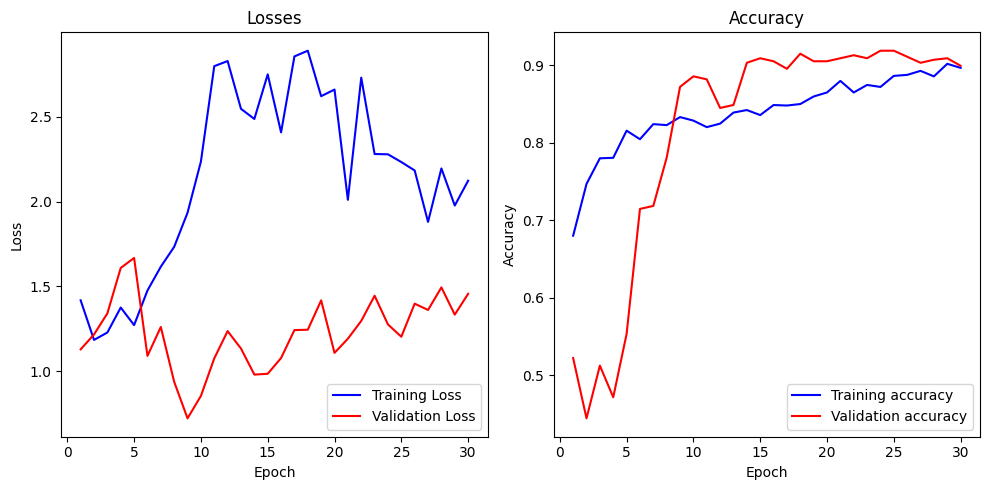

Final Accuracy:  0.8963730335235596
Max Accuracy:  0.9015544056892395
Final Validation Accuracy:  0.8990291357040405
Max Validation Accuracy:  0.9184466004371643


In [90]:
# Adapted from "CNNs for Audio Classification" by Papia Nandi, 2021
# Nandi originally adapted from Deep Learning with Python by Francois Chollet, 2018

# Outputs graphs of Losses and Accuracy of model.
history_dict=history.history
loss_values=history_dict['loss']
accuracy_values=history_dict['accuracy']
val_loss_values = history_dict['val_loss']
val_accuracy_values=history_dict['val_accuracy']
epochs=range(1, len(loss_values)+1)
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(10,5))

ax1.plot(epochs,loss_values,'blue',label='Training Loss')
ax1.plot(epochs,val_loss_values,'red', label='Validation Loss')
ax1.set_title('Losses')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs,accuracy_values,'blue', label='Training accuracy')
ax2.plot(epochs,val_accuracy_values,'red',label='Validation accuracy')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

# Print some accuracy metrics
print('Final Accuracy: ', accuracy_values[-1])
print('Max Accuracy: ', np.max(accuracy_values))
print('Final Validation Accuracy: ', val_accuracy_values[-1])
print('Max Validation Accuracy: ', np.max(val_accuracy_values))

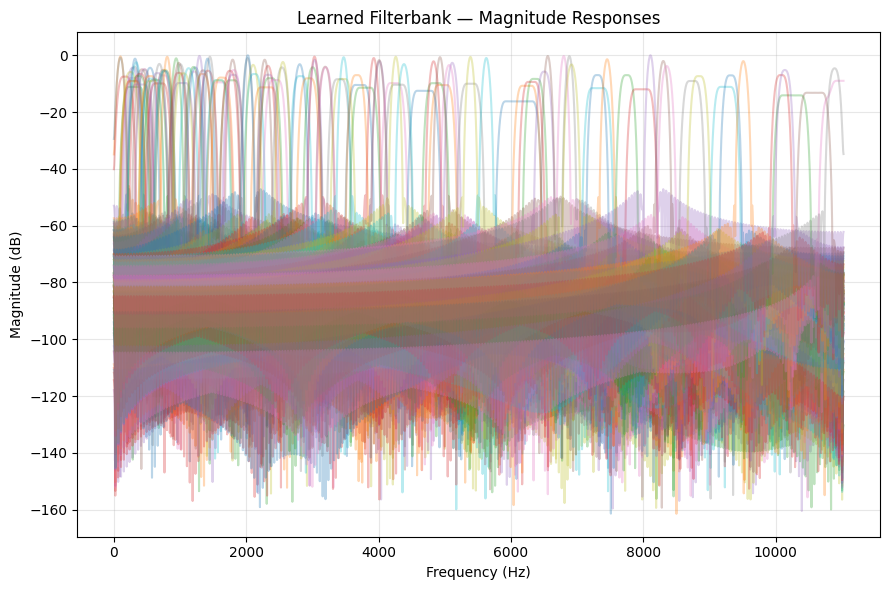

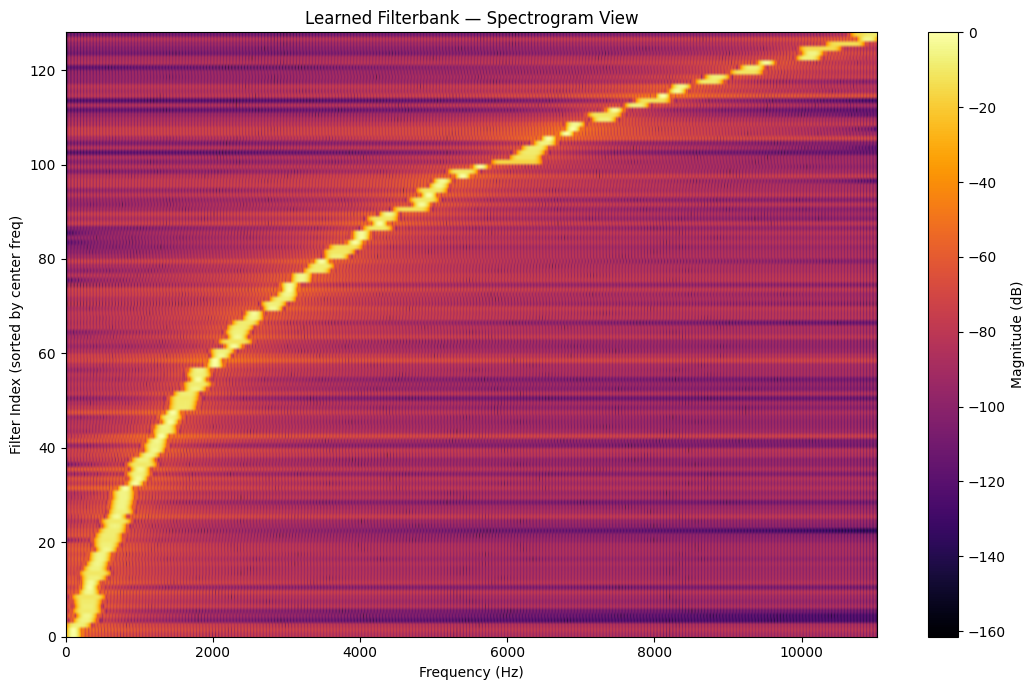

In [115]:
# Extract raw SincConv parameters
sinc_layer = model.get_layer("filterbank")
filt_b1_raw, filt_band_raw = sinc_layer.get_weights()

# Convert (N,1) → (N,)
filt_b1_raw = filt_b1_raw.ravel()
filt_band_raw = filt_band_raw.ravel()

n_filters = len(filt_b1_raw)
fs = sinc_layer.fs
Filt_dim = sinc_layer.Filt_dim

# Minimum enforced inside the layer
min_freq = 50.0
min_band = 50.0

# Convert raw parameters to true frequencies
f1_hz = np.abs(filt_b1_raw) * fs + min_freq
f2_hz = f1_hz + (np.abs(filt_band_raw) * fs + min_band)

# For sorting in the heatmap
centers = (f1_hz + f2_hz) / 2

# Window function
n = np.linspace(0, Filt_dim - 1, Filt_dim)
window = 0.54 - 0.46 * np.cos(2 * np.pi * n / Filt_dim)

def build_sinc_kernel(f1, f2, Filt_dim, fs, window):
    # symmetric time axis
    t = np.arange(-(Filt_dim - 1) / 2, (Filt_dim + 1) / 2) / fs

    # lowpass components
    h1 = 2 * f1 * np.sinc(2 * f1 * t)
    h2 = 2 * f2 * np.sinc(2 * f2 * t)

    # bandpass
    h = h2 - h1

    # window
    h *= window

    # normalize
    return h / (np.max(np.abs(h)) + 1e-12)

# FFT parameters
nfft = 4096
freqs = np.fft.rfftfreq(nfft, 1/fs)
n_freqs = len(freqs)

# Compute magnitude spectra for each filter
spec = np.zeros((n_filters, n_freqs))

for i in range(n_filters):
    h = build_sinc_kernel(f1_hz[i], f2_hz[i], Filt_dim, fs, window)
    H = np.fft.rfft(h, n=nfft)
    mag = np.abs(H)
    spec[i] = 20 * np.log10(mag + 1e-6)

# Normalize to 0 dB peak
spec -= spec.max()

# Plot individual magnitude responses (overlay)
plt.figure(figsize=(9, 6))
for i in range(n_filters):
    plt.plot(freqs, spec[i], alpha=0.3)

plt.title("Learned Filterbank — Magnitude Responses")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Heatmap (sorted by center frequency)
order = np.argsort(centers)

plt.figure(figsize=(11, 7))
plt.imshow(
    spec[order],
    aspect='auto',
    origin='lower',
    extent=[freqs[0], freqs[-1], 0, n_filters],
    cmap='inferno'
)
plt.colorbar(label="Magnitude (dB)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Filter Index (sorted by center freq)")
plt.title("Learned Filterbank — Spectrogram View")
plt.tight_layout()
plt.show()


Notice that the filters are in meaningful shapes and the spectrogram view (stacked filter responses) takes on a easy to understand curve.

Also notice that there are more filters in the lower frequencies. You can see this both by the density of peaks in the overlaid view and the more logarithmic looking curve in the spectrogram view (stacked filter responses).

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K

# Get the layer
sinc_layer = model.get_layer("filterbank")

# This function takes a raw 1D waveform and returns SincConv activations
def run_sincconv(audio):
    audio = audio.reshape(1, -1, 1)   # (batch, time, channels)
    out = sinc_layer(audio).numpy()   # (1, time, filters)
    out = np.squeeze(out, axis=0)     # (time, filters)
    return out.T                      # return (filters, time)

sinc_activations = []   # stores (filters × time) per sample

for sample in sorted(os.listdir(samples)):
    audio, sr = librosa.load(samples+sample, sr=22050)
    audio, _ = librosa.effects.trim(audio, top_db=50)
    audio = librosa.resample(audio, orig_sr=sr, target_sr=22050)

    A = run_sincconv(audio)  # (filters, time)

    sinc_activations.append(A)

sinc_activations = np.array(sinc_activations, dtype=object)  

# ---------------------------------------------------------------
# SincConv1D 3D scatter (analogous to mel-spectrogram scatter)
# ---------------------------------------------------------------

values = [
    ["Clap Samples", 0, 227],
    ["Closed Hat Samples", 227, 469],
    ["Kick Samples", 469, 1217],
    ["Open Hat Samples", 1217, 1331],
    ["Snare Samples", 1331, 2746]
]

for i, value_set in enumerate(values):
    subset = sinc_activations[value_set[1]:value_set[2]]
    
    points_x = []
    points_y = []
    points_z = []
    
    # Loop through samples in the group
    for sample_idx, A in enumerate(subset):
        # A shape: (num_filters, time)
        # threshold: match your mel threshold behavior
        threshold = np.percentile(np.abs(A), 80)

        filt_idx, time_idx = np.nonzero(np.abs(A) > threshold)
        
        points_x.append(time_idx)
        points_y.append(np.full_like(time_idx, sample_idx))
        points_z.append(filt_idx)
    
    # Concatenate all
    x = np.concatenate(points_x)
    y = np.concatenate(points_y)
    z = np.concatenate(points_z)

    fig, ax = plt.subplots(
        1, 1, figsize=(6, 6), subplot_kw={'projection': '3d'}
    )

    ax.scatter3D(
        x,
        y,
        z,
        s=8,
        c=x,       # time = color (same as mel plot)
        cmap='cividis',
        alpha=0.8
    )

    plt.title(f"Figure {i+1}: {value_set[0]} — SincConv Activation")
    plt.xlabel("Time")
    plt.ylabel("Audio File")
    ax.set_zlabel("Filter Index")

plt.show()


ValueError: could not broadcast input array from shape (128,14) into shape (128,)

In [27]:
# Saves model to be used by the prediction Jupyter Notebook
model.save('saved_model/model_raw2_last.keras')